Missing values:
 Age              0
Income           0
SpendingScore    0
Segment          0
dtype: int64

Summary Statistics:
              Age         Income  SpendingScore
count  600.00000     600.000000     600.000000
mean    44.14000   82769.706667      48.360000
std     15.03986   38443.203792      28.884961
min     18.00000   20055.000000       1.000000
25%     32.00000   47667.000000      25.000000
50%     45.00000   79749.000000      46.500000
75%     56.00000  115127.250000      73.000000
max     69.00000  149922.000000      99.000000


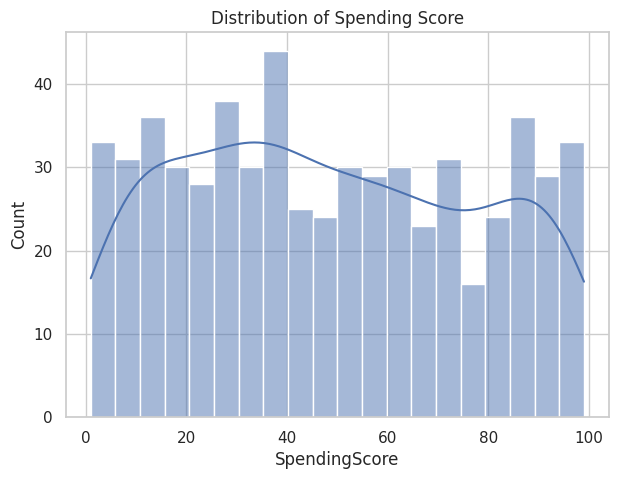

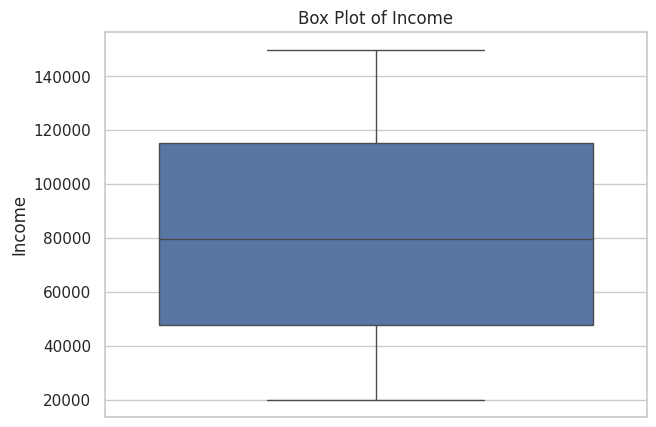

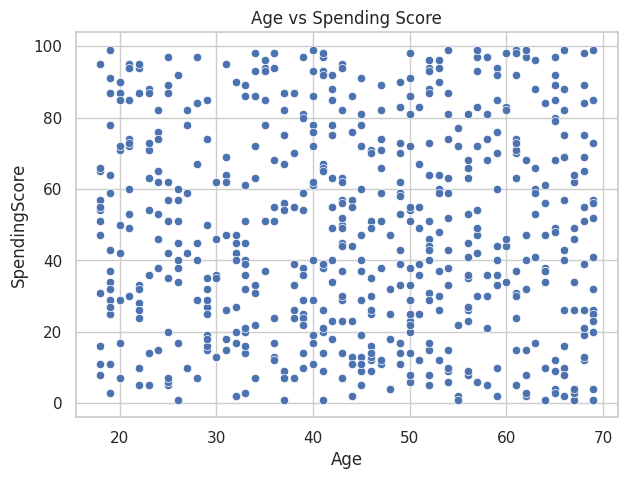


Average Income per Segment:
 Segment
High      88414.016949
Low       80601.038462
Middle    82130.350806
Name: Income, dtype: float64

--- PROJECT SUMMARY ---
Dataset size: 600
Numeric features: Age, Income, SpendingScore
Categorical feature: Segment
Insights:
• Income has visible outliers (box plot).
• Weak relationship between Age and Spending Score.
• High-income group tends to fall into 'High' segment.


In [3]:
# -----------------------------------------------
# IMPORT LIBRARIES
# -----------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# -----------------------------------------------
# 1. SYNTHETIC DATA GENERATION (500+ rows)
# -----------------------------------------------

np.random.seed(42)
n = 600

ages = np.random.randint(18, 70, size=n)
income = np.random.randint(20000, 150000, size=n)
spending_score = np.random.randint(1, 100, size=n)
segments = np.random.choice(["Low", "Middle", "High"], size=n, p=[0.4, 0.4, 0.2])

data = pd.DataFrame({
    "Age": ages,
    "Income": income,
    "SpendingScore": spending_score,
    "Segment": segments
})

# SAVE CSV FOR GITHUB
data.to_csv("synthetic_spending_data.csv", index=False)

# -----------------------------------------------
# 2. DATA CLEANING
# -----------------------------------------------

print("Missing values:\n", data.isnull().sum())
print("\nSummary Statistics:\n", data.describe())

# -----------------------------------------------
# 3. REQUIRED VISUALIZATIONS
# -----------------------------------------------

# Histogram
plt.figure(figsize=(7,5))
sns.histplot(data["SpendingScore"], bins=20, kde=True)
plt.title("Distribution of Spending Score")
plt.savefig("histogram_spending_score.png")
plt.show()

# Box Plot
plt.figure(figsize=(7,5))
sns.boxplot(y=data["Income"])
plt.title("Box Plot of Income")
plt.savefig("boxplot_income.png")
plt.show()

# Scatter Plot
plt.figure(figsize=(7,5))
sns.scatterplot(x=data["Age"], y=data["SpendingScore"])
plt.title("Age vs Spending Score")
plt.savefig("scatter_age_spending.png")
plt.show()

# -----------------------------------------------
# 4. CATEGORY vs NUMERIC ANALYSIS
# -----------------------------------------------

segment_income_mean = data.groupby("Segment")["Income"].mean()
print("\nAverage Income per Segment:\n", segment_income_mean)

# -----------------------------------------------
# 5. TEXT SUMMARY
# -----------------------------------------------

print("\n--- PROJECT SUMMARY ---")
print("Dataset size:", len(data))
print("Numeric features: Age, Income, SpendingScore")
print("Categorical feature: Segment")
print("Insights:")
print("• Income has visible outliers (box plot).")
print("• Weak relationship between Age and Spending Score.")
print("• High-income group tends to fall into 'High' segment.")
